In [1]:
import torch
import torch.nn as nn
import torch.functional as F
import numpy as np
from dataclasses import dataclass
from PIL import Image

device = 'cpu'
if torch.cuda.is_available():
    device = 'cuda'
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = 'mps'
print(device)

cuda


In [2]:
from torch.utils.data import TensorDataset, DataLoader

def read_idx3_images(path):
    with open(path, 'rb') as f:
        # skip the 16 byte header: magic number(4), count(4), rows(4), cols(4)
        data = np.fromfile(f, dtype=np.uint8, offset=16)
    # reshape to (#images, 784) 
    return data.reshape(-1, 784).astype(np.float32) / 255.0

train_images = read_idx3_images('t10k-images.idx3-ubyte')

x_train = torch.tensor(train_images, dtype=torch.float32, device=device)

train_ds = TensorDataset(x_train, x_train)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, )


In [3]:
# hyperparams
@dataclass
class autoencConfig:
    inputsize: int = 784
    bottleneck: int = 8

In [4]:
class AutoEncoder(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.encode = nn.Sequential(
                nn.Linear(784, 512),
                nn.ReLU(),
                nn.Linear(512, 256),
                nn.ReLU(),
                nn.Linear(256, 128),
                nn.ReLU()
        )
        
        self.bottleneck = nn.Linear(128, config.bottleneck)
        
        self.decode = nn.Sequential(
            nn.ReLU(),
            nn.Linear(config.bottleneck, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, config.inputsize)
        )
        
        self.ln = nn.LayerNorm(config.inputsize)
        
        
    def forward(self, x, targets=None):
        x = self.encode(x)
        x = self.bottleneck(x)
        x = self.decode(x)
        
        if targets is None:
            loss = None
        else:
            x = torch.sigmoid(self.ln(x))
            loss = nn.MSELoss()(x, targets)
        return x, loss

In [5]:
model = AutoEncoder(autoencConfig())
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-3)

0.07750409096479416


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

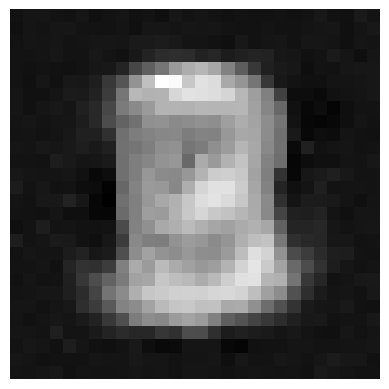

In [6]:
for batch in range(1):
    for images, labels in train_loader:
        output, loss = model(images, labels)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
    print(loss.item())
        

import matplotlib.pyplot as plt

arr = output[0].cpu().detach().reshape(28, 28).numpy()

img = Image.fromarray((arr * 255).clip(0, 255).astype(np.uint8), mode="L")
img.save("reconstructed.png")

plt.imshow(arr, cmap="gray")
plt.axis("off")


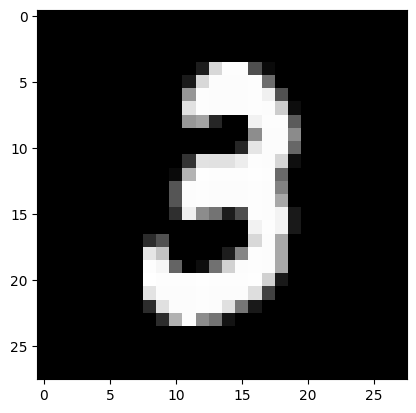

In [7]:
plt.imshow(images[0].cpu().detach().reshape(28, 28).numpy(), cmap="gray")